In [19]:
# Load necessary toolboxes
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import TravelTimeManager
import pygimli.physics.traveltime as tt
from pygimli.physics import ert
import matplotlib
matplotlib.use('TkAgg')
from matplotlib import pyplot as plt
from scipy import interpolate

%matplotlib inline

In [20]:
mgr = ert.ERTManager(sr=False)

# data1 = ert.load('1431N-Line1-Gradient.dat',load=True,verbose=True)
# data = ert.load('Dipole-Dipole_1-2025-09-27-195451_ed.dat',load=True,verbose=True)
data = ert.load('Line1_dipole_dipole_test1.dat',load=True,verbose=True)

# If the importer did not attach sensors, set them explicitly from an xyz file:
# file columns: x z  (for 2-D profiles; y=0).  Units: meters; z positive upward.
elec = np.loadtxt("Line1_electrodes2.txt")
sensors = [pg.Pos(float(x), 0.0, float(z)) for x, z in elec]
data.setSensors(sensors)

assert data.sensorCount() == len(elec)

10/10/25 - 08:42:20 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


In [21]:
xz = np.genfromtxt('Line_1_boundary_rev5.dat',delimiter=',', usecols=(0, 1))
xz

array([[  8.97003746, 656.95700061],
       [ 22.75699255, 655.83913939],
       [ 32.07250274, 654.34865776],
       [ 39.52491089, 653.04448633],
       [ 48.09518027, 653.60341694],
       [ 53.31186598, 654.53496796],
       [ 62.44106596, 652.29924552],
       [ 70.07978432, 652.11293531],
       [ 77.53219247, 652.29924552],
       [ 84.23935981, 655.65282918],
       [ 90.76021695, 656.2117598 ],
       [100.07572714, 657.51593122],
       [104.73348223, 657.70224143],
       [112.18589039, 654.53496796],
       [120.38353936, 651.5540047 ],
       [127.09070669, 649.87721287],
       [134.35680464, 651.18138429],
       [141.8092128 , 653.23079653],
       [152.05627401, 652.85817613],
       [158.76344135, 650.99507409],
       [167.33371072, 649.87721287],
       [179.07125356, 646.5236292 ]])

(<AxesSubplot:>, <matplotlib.colorbar.Colorbar at 0x20f682afe80>)

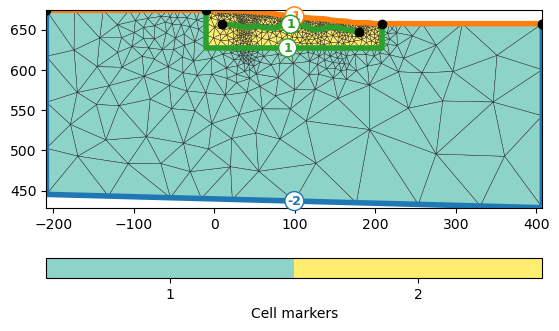

In [22]:

plc = mt.createParaMeshPLC(data, paraDepth=30, boundary=1)
line = mt.createPolygon(xz, marker=1)
plc += line
mesh = mt.createMesh(plc, quality=34.3)
pg.show(mesh, markers=True, showMesh=True)

In [23]:
# mesh = ert.createInversionMesh(
#     data,
#     paraDX=0.5,          # near-surface cell width (m)
#     paraDepth=30,        # desired inversion depth (m)
#     paraMaxCellSize=10,  # growth at depth
#     quality=34,          # triangle quality
#     smoothMesh=True,     # smoother element size transitions
# )

In [24]:
data["k"] = ert.createGeometricFactors(data, numerical=True, mesh=mesh)
data['err'] = ert.estimateError(data, absoluteUError=5e-5, relativeError=0.03)
data.remove(data['rhoa'] < 0)

10/10/25 - 08:42:23 - pyGIMLi - INFO - Save RVector binary
10/10/25 - 08:42:23 - pyGIMLi - INFO - Cache stored: C:\Users\rperr\AppData\Roaming\pygimli\Cache\8737257872526499907


In [25]:
mgr = ert.ERTManager(verbose=True)
inv = mgr.invert(
    data,
    mesh=mesh,
    lam=1,
    robustData=True,     # optional, helps with outliers
    robustModel=True     # optional, promotes blockier models
)

10/10/25 - 08:42:23 - pyGIMLi - INFO - Found 2 regions.
10/10/25 - 08:42:23 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/10/25 - 08:42:23 - pyGIMLi - INFO - Creating apparent resistivies from impedences rhoa = r * k
10/10/25 - 08:42:23 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/10/25 - 08:42:23 - pyGIMLi - INFO - Creating refined mesh (P2) to solve forward task.
10/10/25 - 08:42:23 - pyGIMLi - INFO - Use median(data values)=59.895337825636105
10/10/25 - 08:42:23 - pyGIMLi - INFO - Created startmodel from forward operator: 1041 [59.895337825636105,...,59.895337825636105]
10/10/25 - 08:42:23 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000020E881A5950>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000020E8813CA90>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000020E881A59A0>
min/max (data): 6.69/247
min/max (error): 3.06%/19.16%
min/max (start model): 59.9/59.9
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 5.99 (dPhi = 52.33%) lam: 1
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 0.8 (dPhi = 79.56%) lam: 1.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.80)                   #
################################################################################


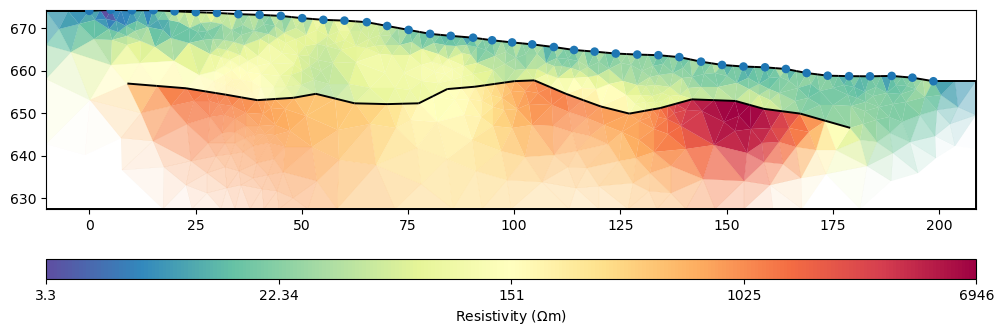

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
ax, cb = mgr.showResult(ax=ax)


In [27]:
expmesh = mgr.paraDomain
model = np.asarray(mgr.model)   # 1 value per cell

cc = expmesh.cellCenters()         # R3Vector of centers
x = np.asarray(pg.x(cc))        # horizontal
z = np.asarray(pg.y(cc))        # vertical in 2-D pyGIMLi (y is “up”)
# If you prefer depth positive downward for Surfer:
# depth = -z

out = np.column_stack([x, z, model, np.log10(model)])
np.savetxt(
    "ert_line1_model_points_boundary5.dat",
    out,
    header="X(m) Z(m) Resistivity(Ohm.m) LogRes",
    fmt="%.4f"
)

Text(0.5, 1.0, 'Standardized coverage (sensitivity proxy)')

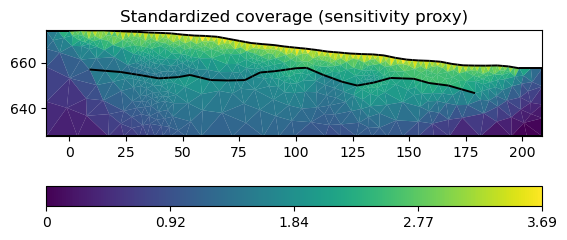

In [ ]:
# After you run mgr.invert(...)
mesh = mgr.paraDomain

cov = mgr.coverage()      # per-cell sensitivity proxy
ax, cb = pg.show(mesh, data=(cov-np.min(cov)), logScale=False, cMap="viridis")
ax.set_title("Coverage (sensitivity proxy)")

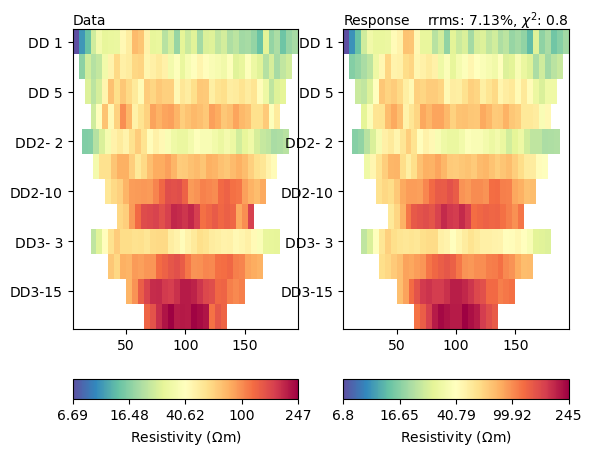

In [43]:
misfit = mgr.showFit()

